In [1]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import pandas as pd


In [2]:
df = pd.read_csv('ab_test_data.csv')

In [3]:
df


,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0
...,...,...,...,...
19993,6763ae9a-515c-473e-af00-0d9c4f6a5bc7,2023-07-06 03:27:37.041104,b,0
19994,ac5600f2-4d16-4503-b115-f1a96728b6d1,2023-07-03 04:20:48.572143,a,0
19995,5a8b2630-209b-4d83-b47f-0f3d9dd568a8,2023-07-23 16:23:49.211910,b,1
19996,b572d68b-26ac-432b-9f88-83e0fdee4ca1,2023-07-03 18:26:20.880675,b,0


In [9]:
df['user_id'].size

19998

In [13]:
df['user_id'].nunique()

19998

In [21]:
a_count = (df['test_group'] == 'a').sum()

In [24]:
b_count = (df['test_group'] == 'b').sum()

In [22]:
a_count

10013

In [25]:
b_count

9985

In [28]:
a_conv = ((df['test_group'] == 'a') & (df['conversion'] == 1)).sum()

In [29]:
a_conv

611

In [30]:
b_conv = ((df['test_group'] == 'b') & (df['conversion'] == 1)).sum()


In [31]:
b_conv

889

In [49]:
conv_a = round((a_conv/a_count)*100 ,2)

In [50]:
conv_a

6.1

In [51]:
conv_b = round((b_conv/b_count)*100 ,2)

In [52]:
conv_b

8.9

In [53]:
df['timestamp'] = pd.to_datetime(df['timestamp'])


In [55]:
start_date = df['timestamp'].min()

In [56]:
start_date

Timestamp('2023-07-03 01:42:34.033708')

In [57]:
finish_date = df['timestamp'].max()

In [58]:
finish_date

Timestamp('2023-07-25 01:41:19.152664')

In [60]:
count_day = (finish_date - start_date).days

In [61]:
count_day

21

In [62]:
group_dates = df.groupby('test_group')['timestamp'].agg(['min', 'max'])

In [63]:
group_dates

,min,max
test_group,,
a,2023-07-03 01:46:14.688840,2023-07-25 01:41:19.152664
b,2023-07-03 01:42:34.033708,2023-07-25 01:35:59.130658


In [64]:
from scipy import stats

alpha = 0.05

observed = pd.crosstab(df['test_group'].values, df['conversion'].values)
statistic, pvalue, dof, expected_values = stats.chi2_contingency(observed)

print(f't-statistic: {round(statistic, 2)}, p-value: {round(pvalue, 2)}')

if pvalue < alpha:
    print('Отримані результати є статистично значущими, тому нульову гіпотезу було відхилено.')
else:
    print('Отримані результати не є статистично значущими, тому немає підстав для відхилення нульової гіпотези.')


t-statistic: 56.14, p-value: 0.0
Отримані результати є статистично значущими, тому нульову гіпотезу було відхилено.


Критерій Хі-квадрат

In [65]:
import seaborn as sns

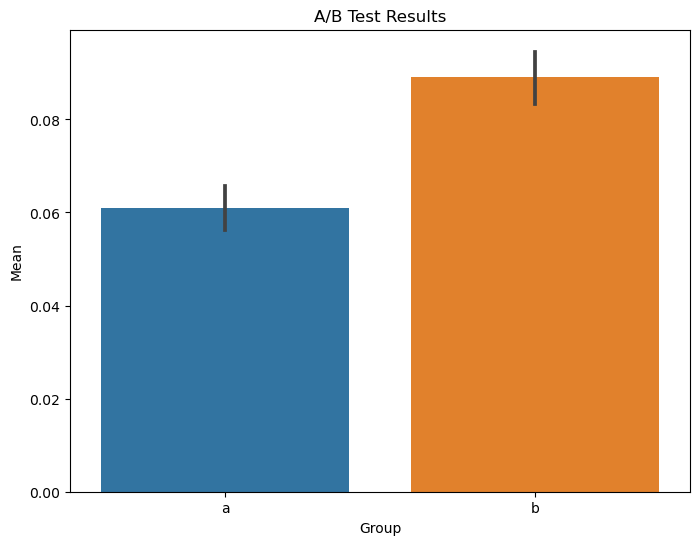

In [67]:
plt.figure(figsize=(8, 6))
sns.barplot(x=df['test_group'], 
            y=df['conversion'], 
            errorbar=('ci', 95)) 

plt.title('A/B Test Results')
plt.xlabel('Group')
plt.ylabel('Mean')

plt.show()

Висновки:
На графіку видно, що група B має вищий середній рівень конверсії, а довірчі інтервали не перекриваються, що підтверджує значущу різницю.
Варіант із 50% знижкою (група B) суттєво підвищив конверсію.
Рекомендується впровадити для всіх користувачів, екран з пропозицією де пропонуємо ту ж підписку, але з припискою про те, що це пропозиція зі знижкою 50%. 

